# DCF估值 - 定增项目内在价值分析

## 分析目标
使用DCF（折现现金流）方法评估定增项目的内在价值，包括：
- 自由现金流预测
- WACC（加权平均资本成本）计算
- 终值计算
- 敏感性分析
- 安全边际评估

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

# 获取字体属性（用于绘图时设置字体）
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ DCF估值模块加载成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ DCF估值模块加载成功


## 1. 项目财务参数设置

In [2]:
# 定增项目基本信息
placement_params = {
    'issue_price': 18,      # 发行价格
    'issue_shares': 5000000,  # 发行数量
    'lockup_period': 6,      # 锁定期（月）
    'current_price': 20,    # 当前价格
    'risk_free_rate': 0.03    # 无风险利率
}

# 公司财务参数
company_params = {
    # 当前财务数据
    'current_revenue': 5000000000,      # 当前收入（50亿元）
    'current_ebit': 800000000,          # 当前EBIT（8亿元）
    'current_tax_rate': 0.25,           # 税率
    'current_deprec': 300000000,        # 折旧摊销（3亿元）
    'current_capex': 400000000,         # 资本支出（4亿元）
    'current_wc': 200000000,            # 营运资本变化（2亿元）
    
    # 增长假设
    'revenue_growth_years': [0.20, 0.18, 0.15, 0.12, 0.10, 0.08, 0.06, 0.05, 0.04, 0.03],
    'ebit_margin': 0.16,                 # EBIT利润率
    
    # WACC参数
    'beta': 1.2,                         # Beta系数
    'risk_free_rate': 0.03,              # 无风险利率
    'market_risk_premium': 0.07,         # 市场风险溢价
    'cost_of_debt': 0.06,                # 债务成本
    'target_debt_ratio': 0.30,           # 目标债务比率
    'tax_rate': 0.25,                    # 税率
    
    # 终值参数
    'terminal_growth': 0.025,            # 永续增长率
    'exit_multiple': 12.0,               # 退出倍数（备用）
}

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**placement_params)

print('=== 定增项目基本信息 ===')
print(f"发行价格: {placement_params['issue_price']} 元/股")
print(f"当前价格: {placement_params['current_price']} 元/股")
print(f"折价率: {(placement_params['current_price']/placement_params['issue_price'] - 1)*100:.2f}%")
print(f"发行数量: {placement_params['issue_shares']:,} 股")
print(f"融资金额: {placement_params['issue_price'] * placement_params['issue_shares'] / 100000000:.2f} 亿元")

print('\n=== 公司财务参数 ===')
print(f"当前收入: {company_params['current_revenue']/100000000:.2f} 亿元")
print(f"当前EBIT: {company_params['current_ebit']/100000000:.2f} 亿元")
print(f"EBIT利润率: {company_params['ebit_margin']*100:.1f}%")

=== 定增项目基本信息 ===
发行价格: 18 元/股
当前价格: 20 元/股
折价率: 11.11%
发行数量: 5,000,000 股
融资金额: 0.90 亿元

=== 公司财务参数 ===
当前收入: 50.00 亿元
当前EBIT: 8.00 亿元
EBIT利润率: 16.0%


## 2. WACC计算

In [3]:
def calculate_wacc(params):
    """计算加权平均资本成本"""
    # 股权成本（CAPM）
    cost_of_equity = params['risk_free_rate'] + params['beta'] * params['market_risk_premium']
    
    # 税后债务成本
    after_tax_cost_of_debt = params['cost_of_debt'] * (1 - params['tax_rate'])
    
    # WACC
    wacc = (cost_of_equity * (1 - params['target_debt_ratio']) + 
            after_tax_cost_of_debt * params['target_debt_ratio'])
    
    return {
        'cost_of_equity': cost_of_equity,
        'after_tax_cost_of_debt': after_tax_cost_of_debt,
        'wacc': wacc
    }

wacc_result = calculate_wacc(company_params)

print('=== WACC计算结果 ===')
print(f"\n股权成本 (CAPM):")
print(f"  无风险利率: {company_params['risk_free_rate']*100:.2f}%")
print(f"  Beta: {company_params['beta']}")
print(f"  市场风险溢价: {company_params['market_risk_premium']*100:.2f}%")
print(f"  股权成本: {wacc_result['cost_of_equity']*100:.2f}%")

print(f"\n债务成本:")
print(f"  税前债务成本: {company_params['cost_of_debt']*100:.2f}%")
print(f"  税率: {company_params['tax_rate']*100:.1f}%")
print(f"  税后债务成本: {wacc_result['after_tax_cost_of_debt']*100:.2f}%")

print(f"\n资本结构:")
print(f"  目标债务比率: {company_params['target_debt_ratio']*100:.1f}%")
print(f"  目标股权比率: {(1-company_params['target_debt_ratio'])*100:.1f}%")

print(f"\n✅ WACC: {wacc_result['wacc']*100:.2f}%")

=== WACC计算结果 ===

股权成本 (CAPM):
  无风险利率: 3.00%
  Beta: 1.2
  市场风险溢价: 7.00%
  股权成本: 11.40%

债务成本:
  税前债务成本: 6.00%
  税率: 25.0%
  税后债务成本: 4.50%

资本结构:
  目标债务比率: 30.0%
  目标股权比率: 70.0%

✅ WACC: 9.33%


## 3. 自由现金流预测

In [4]:
# 预测期（通常10年）
projection_years = 10

# 初始化预测数据
fcf_projection = []

revenue = company_params['current_revenue']
for i, growth_rate in enumerate(company_params['revenue_growth_years'][:projection_years], 1):
    # 收入增长
    revenue *= (1 + growth_rate)
    
    # EBIT
    ebit = revenue * company_params['ebit_margin']
    
    # 税后营业利润
    nopat = ebit * (1 - company_params['current_tax_rate'])
    
    # 加回折旧摊销
    deprec = company_params['current_deprec'] * (1 + 0.05)**(i-1)  # 假设折旧年增长5%
    
    # 减去资本支出
    capex = company_params['current_capex'] * (1 + 0.05)**(i-1)  # 假设资本支出年增长5%
    
    # 减去营运资本变化
    wc_change = company_params['current_wc'] * (1 + 0.03)**(i-1)  # 假设WC变化年增长3%
    
    # 自由现金流
    fcf = nopat + deprec - capex - wc_change
    
    fcf_projection.append({
        'year': i,
        'revenue': revenue,
        'ebit': ebit,
        'nopat': nopat,
        'depreciation': deprec,
        'capex': capex,
        'wc_change': wc_change,
        'fcf': fcf
    })

df_fcf = pd.DataFrame(fcf_projection)

# 显示预测结果
print('=== 自由现金流预测 ===')
print(f"{'年份':<6} {'收入(亿)':<12} {'EBIT(亿)':<12} {'FCF(亿)':<12} {'FCF增长率':<12}")
print('-'*54)

for _, row in df_fcf.iterrows():
    growth = ((row['fcf'] / df_fcf.loc[0, 'fcf']) - 1) * 100 if row['year'] == 1 else \
             ((row['fcf'] / df_fcf.loc[row['year']-2, 'fcf']) - 1) * 100
    print(f"{int(row['year']):<6} {row['revenue']/100000000:<12.2f} {row['ebit']/100000000:<12.2f} {row['fcf']/100000000:<12.2f} {growth:<11.1f}%")

=== 自由现金流预测 ===
年份     收入(亿)        EBIT(亿)      FCF(亿)       FCF增长率      
------------------------------------------------------
1      60.00        9.60         4.20         0.0        %
2      70.80        11.33        5.39         28.2       %
3      81.42        13.03        6.55         21.5       %
4      91.19        14.59        7.60         16.1       %
5      100.31       16.05        8.57         12.8       %
6      108.33       17.33        9.41         9.7        %
7      114.83       18.37        10.05        6.9        %
8      120.58       19.29        10.60        5.5        %
9      125.40       20.06        11.04        4.1        %
10     129.16       20.67        11.34        2.7        %


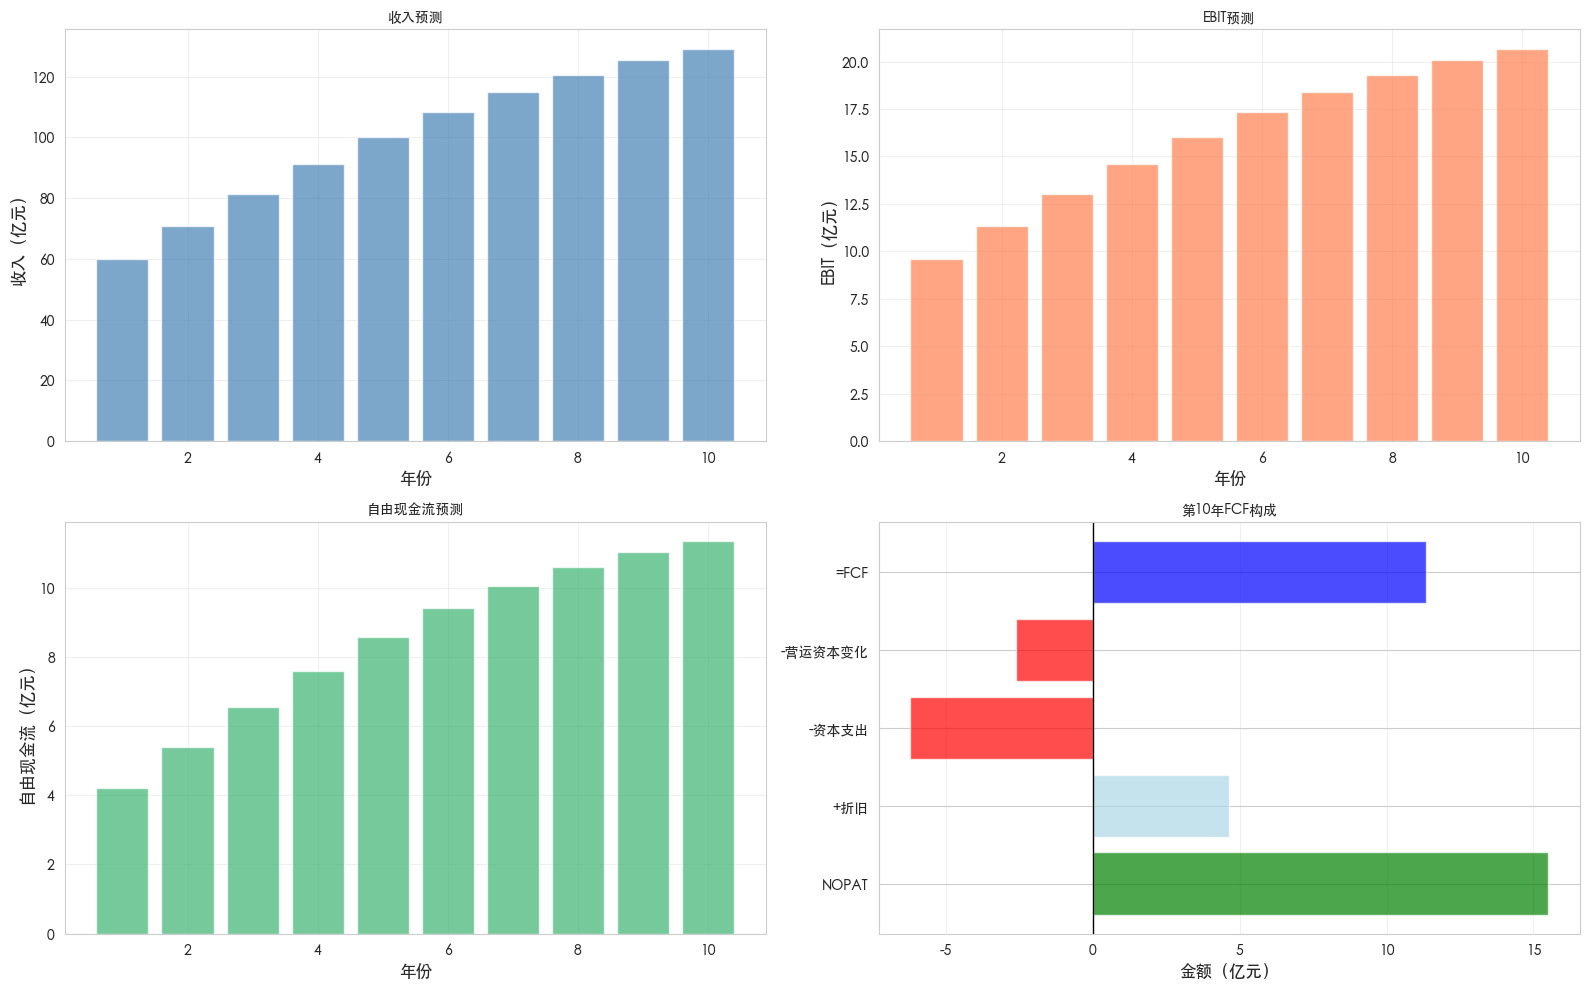

In [5]:
# 可视化自由现金流预测
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# 1. 收入增长
ax1.bar(df_fcf['year'], df_fcf['revenue']/100000000, color='steelblue', alpha=0.7)
ax1.set_xlabel('年份', fontsize=12, fontproperties=font_prop)
ax1.set_ylabel('收入（亿元）', fontsize=12, fontproperties=font_prop)
ax1.set_title('收入预测', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

# 2. EBIT增长
ax2.bar(df_fcf['year'], df_fcf['ebit']/100000000, color='coral', alpha=0.7)
ax2.set_xlabel('年份', fontsize=12, fontproperties=font_prop)
ax2.set_ylabel('EBIT（亿元）', fontsize=12, fontproperties=font_prop)
ax2.set_title('EBIT预测', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

# 3. 自由现金流
bars = ax3.bar(df_fcf['year'], df_fcf['fcf']/100000000, color='mediumseagreen', alpha=0.7)
ax3.set_xlabel('年份', fontsize=12, fontproperties=font_prop)
ax3.set_ylabel('自由现金流（亿元）', fontsize=12, fontproperties=font_prop)
ax3.set_title('自由现金流预测', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)
ax3.grid(True, alpha=0.3)

# 4. FCF构成（瀑布图）
last_year = df_fcf.iloc[-1]
components = ['NOPAT', '+折旧', '-资本支出', '-营运资本变化', '=FCF']
values = [
    last_year['nopat']/100000000,
    last_year['depreciation']/100000000,
    -last_year['capex']/100000000,
    -last_year['wc_change']/100000000,
    last_year['fcf']/100000000
]
colors_waterfall = ['green', 'lightblue', 'red', 'red', 'blue']

ax4.barh(components, values, color=colors_waterfall, alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('金额（亿元）', fontsize=12, fontproperties=font_prop)
ax4.set_title(f'第{int(last_year["year"])}年FCF构成', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax4.get_xticklabels():
    label.set_fontproperties(font_prop)
ax4.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 企业价值与股权价值计算

In [6]:
# 计算现值
wacc = wacc_result['wacc']
pv_fcf = []
total_pv = 0

for _, row in df_fcf.iterrows():
    pv = row['fcf'] / ((1 + wacc) ** row['year'])
    pv_fcf.append(pv)
    total_pv += pv

df_fcf['pv'] = pv_fcf

# 终值计算（永续增长法）
last_fcf = df_fcf.iloc[-1]['fcf']
terminal_value = last_fcf * (1 + company_params['terminal_growth']) / (wacc - company_params['terminal_growth'])
pv_terminal_value = terminal_value / ((1 + wacc) ** projection_years)

# 企业价值
enterprise_value = total_pv + pv_terminal_value

# 假设净债务
net_debt = 2000000000  # 20亿元

# 股权价值
equity_value = enterprise_value - net_debt

# 假设总股本
total_shares = 500000000  # 5亿股

# 每股价值
value_per_share = equity_value / total_shares

print('=== DCF估值结果 ===')
print(f"\n现金流现值总计: {total_pv/100000000:.2f} 亿元")
print(f"终值: {terminal_value/100000000:.2f} 亿元")
print(f"终值现值: {pv_terminal_value/100000000:.2f} 亿元")
print(f"\n企业价值: {enterprise_value/100000000:.2f} 亿元")
print(f"净债务: {net_debt/100000000:.2f} 亿元")
print(f"股权价值: {equity_value/100000000:.2f} 亿元")
print(f"\n总股本: {total_shares/100000000:.2f} 亿股")
print(f"✅ 每股内在价值: {value_per_share:.2f} 元")

print(f"\n=== 估值对比 ===")
print(f"DCF内在价值: {value_per_share:.2f} 元/股")
print(f"当前市价: {placement_params['current_price']} 元/股")
print(f"发行价格: {placement_params['issue_price']} 元/股")

# 计算安全边际
margin_of_safety_vs_market = (value_per_share - placement_params['current_price']) / placement_params['current_price']
margin_of_safety_vs_issue = (value_per_share - placement_params['issue_price']) / placement_params['issue_price']

print(f"\n安全边际（相对市价）: {margin_of_safety_vs_market*100:.1f}%")
print(f"安全边际（相对发行价）: {margin_of_safety_vs_issue*100:.1f}%")

=== DCF估值结果 ===

现金流现值总计: 49.84 亿元
终值: 170.16 亿元
终值现值: 69.74 亿元

企业价值: 119.58 亿元
净债务: 20.00 亿元
股权价值: 99.58 亿元

总股本: 5.00 亿股
✅ 每股内在价值: 19.92 元

=== 估值对比 ===
DCF内在价值: 19.92 元/股
当前市价: 20 元/股
发行价格: 18 元/股

安全边际（相对市价）: -0.4%
安全边际（相对发行价）: 10.6%


## 5. 估值敏感性分析

In [ ]:
# DCF估值敏感性分析 - 不同WACC和永续增长率下的估值
# 创建敏感性分析矩阵

wacc_range = np.linspace(0.07, 0.13, 7)  # 7%到13%的WACC
growth_range = np.linspace(0.01, 0.04, 7)  # 1%到4%的永续增长率

pivot_data = []
for g in growth_range:
    row = []
    for w in wacc_range:
        # 计算企业价值
        total_pv_temp = sum([fcf / ((1 + w) ** (i+1)) for i, fcf in enumerate(df_fcf['fcf'].values)])
        
        # 终值
        last_fcf = df_fcf.iloc[-1]['fcf']
        tv = last_fcf * (1 + g) / (w - g) if w > g else 0
        pv_tv = tv / ((1 + w) ** projection_years)
        
        # 企业价值
        ev = total_pv_temp + pv_tv
        
        # 股权价值
        eq = ev - net_debt
        
        # 每股价值
        vps = eq / total_shares
        row.append(vps)
    
    pivot_data.append(row)

# 创建透视表
pivot_table = pd.DataFrame(
    pivot_data,
    index=[f'{g*100:.1f}%' for g in growth_range],
    columns=[f'{w*100:.1f}%' for w in wacc_range]
)

print('\n=== DCF估值敏感性分析 ===')
print(f"每股价值（元）在不同WACC和永续增长率假设下:")
print(pivot_table)

# 高亮显示基准情况下的估值
base_wacc = wacc_result['wacc']
base_growth = company_params['terminal_growth']
print(f"\n基准假设: WACC={base_wacc*100:.2f}%, 永续增长率={base_growth*100:.1f}%")
print(f"基准估值: {value_per_share:.2f} 元/股")

NameError: name 'pivot_table' is not defined

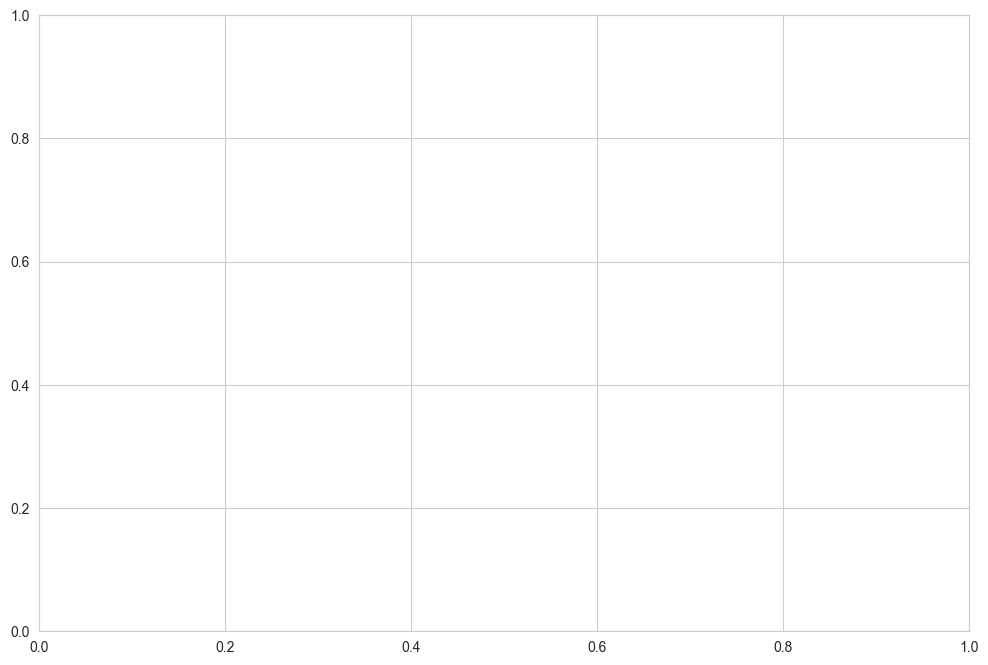

In [7]:
# 可视化
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', center=placement_params['current_price'],
           cbar_kws={'label': '每股价值（元）'}, ax=ax)
ax.set_xlabel('永续增长率', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('WACC', fontsize=12, fontproperties=font_prop)
ax.set_title('DCF估值敏感性分析矩阵（每股价值：元）', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
plt.tight_layout()
plt.show()

## 6. 定增项目投资价值评估

In [ ]:
# 计算投资价值指标
investment_metrics = {
    # 估值指标
    'intrinsic_value': value_per_share,
    'current_price': placement_params['current_price'],
    'issue_price': placement_params['issue_price'],
    
    # 安全边际
    'margin_of_safety_market': margin_of_safety_vs_market,
    'margin_of_safety_issue': margin_of_safety_vs_issue,
    
    # 折价率
    'discount_to_market': (placement_params['current_price'] / value_per_share - 1),
    'discount_to_intrinsic': (placement_params['issue_price'] / value_per_share - 1),
    
    # DCF参数
    'wacc': wacc,
    'terminal_growth': company_params['terminal_growth'],
    
    # 预期收益率
    'expected_annual_return': (value_per_share / placement_params['issue_price']) ** (12/placement_params['lockup_period']) - 1,
}

# 综合评分
score = 0
score_factors = []

# 1. 安全边际评分 (0-30分)
if investment_metrics['margin_of_safety_issue'] >= 0.3:
    safety_score = 30
    score_factors.append("✅ 安全边际充足 (≥30%)")
elif investment_metrics['margin_of_safety_issue'] >= 0.15:
    safety_score = 20
    score_factors.append("⚠️ 安全边际一般 (15%-30%)")
elif investment_metrics['margin_of_safety_issue'] >= 0:
    safety_score = 10
    score_factors.append("⚠️ 安全边际较低 (0%-15%)")
else:
    safety_score = 0
    score_factors.append("❌ 无安全边际 (<0%)")

score += safety_score

# 2. 发行折价评分 (0-20分)
if investment_metrics['discount_to_intrinsic'] <= -0.2:
    discount_score = 20
    score_factors.append(f"✅ 发行折价大 ({investment_metrics['discount_to_intrinsic']*100:.1f}%)")
elif investment_metrics['discount_to_intrinsic'] <= -0.1:
    discount_score = 15
    score_factors.append(f"⚠️ 发行折价一般 ({investment_metrics['discount_to_intrinsic']*100:.1f}%)")
else:
    discount_score = 5
    score_factors.append(f"❌ 发行折价小 ({investment_metrics['discount_to_intrinsic']*100:.1f}%)")

score += discount_score

# 3. 预期收益率评分 (0-30分)
if investment_metrics['expected_annual_return'] >= 0.30:
    return_score = 30
    score_factors.append(f"✅ 预期收益率高 (≥30%)")
elif investment_metrics['expected_annual_return'] >= 0.20:
    return_score = 20
    score_factors.append(f"⚠️ 预期收益率一般 (20%-30%)")
elif investment_metrics['expected_annual_return'] >= 0.10:
    return_score = 10
    score_factors.append(f"⚠️ 预期收益率较低 (10%-20%)")
else:
    return_score = 5
    score_factors.append(f"❌ 预期收益率低 (<10%)")

score += return_score

# 4. WACC合理性评分 (0-10分)
if 0.08 <= wacc <= 0.12:
    wacc_score = 10
    score_factors.append(f"✅ WACC合理 ({wacc*100:.1f}%)")
else:
    wacc_score = 5
    score_factors.append(f"⚠️ WACC需复核 ({wacc*100:.1f}%)")

score += wacc_score

# 5. 增长假设合理性 (0-10分)
avg_growth = np.mean(company_params['revenue_growth_years'][:5])
if avg_growth <= 0.20:
    growth_score = 10
    score_factors.append(f"✅ 增长假设合理 ({avg_growth*100:.1f}%)")
else:
    growth_score = 5
    score_factors.append(f"⚠️ 增长假设乐观 ({avg_growth*100:.1f}%)")

score += growth_score

print('\n' + '='*70)
print('定增项目DCF估值投资价值评估')
print('='*70)

print(f"\n📊 核心估值指标:")
print(f"   DCF内在价值: {investment_metrics['intrinsic_value']:.2f} 元/股")
print(f"   当前市价: {investment_metrics['current_price']:.2f} 元/股")
print(f"   发行价格: {investment_metrics['issue_price']:.2f} 元/股")

print(f"\n💰 安全边际分析:")
print(f"   相对市价: {investment_metrics['margin_of_safety_market']*100:.1f}%")
print(f"   相对发行价: {investment_metrics['margin_of_safety_issue']*100:.1f}%")

print(f"\n📈 预期收益:")
print(f"   预期年化收益率: {investment_metrics['expected_annual_return']*100:.1f}%")

print(f"\n🎯 评分因素:")
for factor in score_factors:
    print(f"   {factor}")

print(f"\n📊 总投资价值评分: {score}/100")

# 投资建议
if score >= 80:
    recommendation = "🟢 强烈推荐 - DCF显示显著低估"
elif score >= 60:
    recommendation = "🟡 谨慎推荐 - DCF显示合理偏低"
elif score >= 40:
    recommendation = "🟠 观望 - DCF显示估值合理"
else:
    recommendation = "🔴 不推荐 - DCF显示估值偏高"

print(f"\n{recommendation}")

## 7. 估值可视化对比

In [ ]:
# 创建估值对比图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. 估值对比柱状图
valuation_labels = ['DCF内在价值', '当前市价', '发行价格']
valuation_values = [investment_metrics['intrinsic_value'], 
                   investment_metrics['current_price'], 
                   investment_metrics['issue_price']]
colors_val = ['green' if v > investment_metrics['issue_price'] else 'red' for v in valuation_values]

bars = ax1.barh(valuation_labels, valuation_values, color=colors_val, alpha=0.7)
ax1.set_xlabel('价格（元/股）', fontsize=12, fontproperties=font_prop)
ax1.set_title('估值对比', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, axis='x', alpha=0.3)
# 添加数值标签
for bar, value in zip(bars, valuation_values):
    ax1.text(value, bar.get_y() + bar.get_height()/2, 
            f' {value:.2f}', va='center', fontsize=11)

# 2. 安全边际
margin_labels = ['相对市价', '相对发行价']
margin_values = [investment_metrics['margin_of_safety_market']*100, 
               investment_metrics['margin_of_safety_issue']*100]
colors_margin = ['green' if m > 0 else 'red' for m in margin_values]

bars2 = ax2.barh(margin_labels, margin_values, color=colors_margin, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('安全边际 (%)', fontsize=12, fontproperties=font_prop)
ax2.set_title('安全边际分析', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, axis='x', alpha=0.3)
for bar, value in zip(bars2, margin_values):
    ax2.text(value, bar.get_y() + bar.get_height()/2, 
            f' {value:.1f}%', va='center', fontsize=11)

# 3. 折价率
discount_labels = ['市价折价率', '发行价折价率']
discount_values = [investment_metrics['discount_to_market']*100, 
                  investment_metrics['discount_to_intrinsic']*100]

bars3 = ax3.barh(discount_labels, discount_values, color='steelblue', alpha=0.7)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('折价率 (%)', fontsize=12, fontproperties=font_prop)
ax3.set_title('折价率分析（负值表示折价）', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
ax3.grid(True, axis='x', alpha=0.3)
for bar, value in zip(bars3, discount_values):
    ax3.text(value, bar.get_y() + bar.get_height()/2, 
            f' {value:.1f}%', va='center', fontsize=11)

# 4. 投资指标仪表板
metrics_data = {
    '安全边际\n(发行价)': f"{investment_metrics['margin_of_safety_issue']*100:.1f}%",
    '预期年化\n收益率': f"{investment_metrics['expected_annual_return']*100:.1f}%",
    'WACC': f"{wacc*100:.1f}%",
    '投资评分': f"{score}/100"
}

y_pos = np.arange(len(metrics_data))
ax4.barh(y_pos, [100]*len(metrics_data), color=['green' if score >= 60 else 'orange' if score >= 40 else 'red'], 
        alpha=0.3)
ax4.axis('off')
ax4.set_title('关键指标汇总', fontsize=14, fontweight='bold', fontproperties=font_prop)

for i, (key, value) in enumerate(metrics_data.items()):
    ax4.text(10, i, f"{key}: {value}", fontsize=12, va='center', fontweight='bold', fontproperties=font_prop)

plt.tight_layout()
plt.show()

## 8. DCF估值结论

In [ ]:
print('\n' + '='*70)
print('DCF估值分析结论')
print('='*70)

print(f"\n📋 估值方法: DCF（自由现金流折现）")
print(f"   折现率 (WACC): {wacc*100:.2f}%")
print(f"   永续增长率: {company_params['terminal_growth']*100:.1f}%")
print(f"   预测期: {projection_years} 年")

print(f"\n💡 核心发现:")
print(f"   1. DCF内在价值: {value_per_share:.2f} 元/股")
if value_per_share > placement_params['issue_price']:
    print(f"      相比发行价有 {margin_of_safety_vs_issue*100:.1f}% 的安全边际")
else:
    print(f"      相比发行价低 {abs(margin_of_safety_vs_issue)*100:.1f}%")

print(f"\n   2. 预期年化收益率: {investment_metrics['expected_annual_return']*100:.1f}%")
if investment_metrics['expected_annual_return'] > 0.20:
    print(f"      收益率吸引力较高")
elif investment_metrics['expected_annual_return'] > 0.10:
    print(f"      收益率吸引力一般")
else:
    print(f"      收益率吸引力较低")

print(f"\n⚠️ 主要假设与风险:")
print(f"   1. 收入增长假设: {company_params['revenue_growth_years'][0]*100:.1f}% (首年)")
print(f"   2. EBIT利润率: {company_params['ebit_margin']*100:.1f}%")
print(f"   3. WACC假设: {wacc*100:.2f}%")
print(f"   4. 终值占比: {pv_terminal_value/(pv_terminal_value+total_pv)*100:.1f}%")

print(f"\n💼 投资建议: {recommendation}")

if score >= 60:
    print(f"\n✅ 建议行动:")
    print(f"   1. 可以考虑参与定增")
    print(f"   2. 建议与其它估值方法（相对估值等）交叉验证")
    print(f"   3. 关注关键假设的实现情况")
else:
    print(f"\n⚠️ 建议行动:")
    print(f"   1. 重新审视估值假设")
    print(f"   2. 寻求更具安全边际的投资机会")
    print(f"   3. 考虑等待更好的入场时机")